# Biology demonstration: do different counting methods give different biological answers?

Exploratory analysis, 2026-08-28. Not part of the frozen benchmark.

Quest 2): the paper never uses the method to learn
anything. Can we show that the six benchmarked methods disagree about whether
ecDNA burden changed under treatment?

Approach: experimental conditions are encoded in the `unique_id` filename
tokens. Every method already has frozen per-image predictions on the 1,145
benchmark images, so treated-vs-control contrasts can be computed with no new
inference.

Outputs → /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning

In [1]:
from pathlib import Path
import sys, re, json, platform
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

PROJ   = Path("/proj/brunk_ecdna_cv_project/Poorya/ecdna-bench")
OUTDIR = Path("/proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning")
FIGDIR = OUTDIR / "figures"
TABDIR = OUTDIR / "tables"
for d in (FIGDIR, TABDIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)

MODELS = ["ecCount (peaks)", "ecCount (threshold mask)", "Classic (after opt)",
          "Label Engine", "MIA", "ecSeg"]
ORDER  = ["Ground truth"] + MODELS

print("python  :", sys.version.split()[0])
print("pandas  :", pd.__version__, "| numpy:", np.__version__)
print("host    :", platform.node())
print("outputs :", OUTDIR)

python  : 3.10.16
pandas  : 2.2.3 | numpy: 2.2.5
host    : c0300ood18.ll.unc.edu
outputs : /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning


In [2]:
candidates = sorted(PROJ.rglob("per_image_metrics.csv"))
for i, p in enumerate(candidates):
    n = sum(1 for _ in open(p)) - 1
    print(f"[{i}] rows={n:>6}  {p.relative_to(PROJ)}")

[0] rows=  2290  outputs/classical_bfr_aft/and_matching/per_image_metrics.csv
[1] rows=  2290  outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
[2] rows=  6870  release/frozen_results/and_matching/per_image_metrics.csv
[3] rows=  6870  release/frozen_results/or_matching/per_image_metrics.csv
[4] rows=  2290  release/river_roi_run/frozen_results/and_matching/per_image_metrics.csv
[5] rows=  2290  release/river_roi_run/frozen_results/or_matching/per_image_metrics.csv


In [3]:
PIM_PATH = PROJ / "release/frozen_results/or_matching/per_image_metrics.csv"
assert PIM_PATH.is_file(), f"not found: {PIM_PATH}"

# A path assertion cannot catch a copied directory, and river_roi_run/ now holds
# its own or_matching/per_image_metrics.csv. Assert the OR signature instead:
# under OR, ecCount peaks outranks threshold; under AND the order inverts
# (0.7085 vs 0.7652). Cell 2's rglob listing is diagnostic only — never index it.
_pre = pd.read_csv(PIM_PATH)


def _pooled_f1(d):
    tp, fp, fn = d.obj_tp.sum(), d.obj_fp.sum(), d.obj_fn.sum()
    return 2 * tp / (2 * tp + fp + fn)


_f1_pk = _pooled_f1(_pre[_pre.model == "ecCount (peaks)"])
_f1_th = _pooled_f1(_pre[_pre.model == "ecCount (threshold mask)"])
assert _f1_pk > _f1_th, (
    f"AND-POLICY DATA: peaks {_f1_pk:.4f} <= threshold {_f1_th:.4f}. "
    "Canonical policy is OR.")
assert round(_f1_pk, 3) == 0.942, f"peaks pooled F1 {_f1_pk:.4f}, locked 0.942"
assert len(_pre) == 6870, f"{len(_pre)} rows, expected 6,870 (1,145 × 6 models)"
del _pre

print("preflight OK — OR matching policy")
print(f"  peaks {_f1_pk:.4f} > threshold {_f1_th:.4f} · 6,870 rows")
print("d_max = 20 px, IoU_min = 0.1, alpha = 0.5, 8-connectivity, min_area = 3 px")
print(PIM_PATH)

preflight OK — OR matching policy
  peaks 0.9420 > threshold 0.9174 · 6,870 rows
d_max = 20 px, IoU_min = 0.1, alpha = 0.5, 8-connectivity, min_area = 3 px
/proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/or_matching/per_image_metrics.csv


In [4]:
pim = pd.read_csv(PIM_PATH)
print("shape:", pim.shape)
print("\nmodels present:")
print(pim.model.value_counts().to_string())

missing = set(MODELS) - set(pim.model.unique())
assert not missing, (
    f"Missing models {missing}. You are probably pointed at the classical "
    "before/after comparison output (2 models, 2,290 rows) rather than the "
    "six-model benchmark."
)
assert pim.uid.nunique() == 1145, f"expected 1,145 UIDs, got {pim.uid.nunique()}"
assert len(pim) == 1145 * 6, f"expected 6,870 rows, got {len(pim)}"

print("\nsplits:", pim[pim.model == MODELS[0]].split.value_counts().to_dict())
print("cell lines:", pim[pim.model == MODELS[0]].cell_line.value_counts().to_dict())

shape: (6870, 31)

models present:
model
ecCount (peaks)             1145
ecCount (threshold mask)    1145
MIA                         1145
Label Engine                1145
Classic (after opt)         1145
ecSeg                       1145

splits: {'train': 800, 'test': 175, 'val': 170}
cell lines: {'NCI-H2170': 888, 'SNU16': 123, 'NCI-H716': 70, 'COLO320DM': 64}


In [5]:
LOCKED = {
    "ecCount (peaks)":          (13.1,   0.4),
    "ecCount (threshold mask)": (18.1, -11.4),
    "Label Engine":             (36.0, -28.8),
    "MIA":                      (47.0, -40.6),
    "Classic (after opt)":      (44.9, -24.3),
    "ecSeg":                   (121.5, -118.5),
}

err = pim.pred_count - pim.gt_count
chk = (pim.assign(ae=err.abs(), se=err)
          .groupby("model")
          .agg(count_MAE=("ae", "mean"), count_bias=("se", "mean")))
chk["locked_MAE"]  = chk.index.map(lambda m: LOCKED[m][0])
chk["locked_bias"] = chk.index.map(lambda m: LOCKED[m][1])
chk["MAE_ok"]  = (chk.count_MAE  - chk.locked_MAE ).abs() < 0.05
chk["bias_ok"] = (chk.count_bias - chk.locked_bias).abs() < 0.05
print(chk.round(3).to_string())

assert chk.MAE_ok.all() and chk.bias_ok.all(), \
    "Recomputed metrics do not match the locked §3 numbers — STOP."
print("\nAll six models reproduce the locked count MAE and bias. Proceed.")

                          count_MAE  count_bias  locked_MAE  locked_bias  MAE_ok  bias_ok
model                                                                                    
Classic (after opt)          44.924     -24.285        44.9        -24.3    True     True
Label Engine                 36.028     -28.763        36.0        -28.8    True     True
MIA                          46.952     -40.620        47.0        -40.6    True     True
ecCount (peaks)              13.112       0.355        13.1          0.4    True     True
ecCount (threshold mask)     18.077     -11.441        18.1        -11.4    True     True
ecSeg                       121.486    -118.468       121.5       -118.5    True     True

All six models reproduce the locked count MAE and bias. Proceed.


In [6]:
def parse_condition(uid: str) -> str:
    """Strip the trailing image index and any _a/_b/_ab suffix."""
    return re.sub(r"_(\d+)(_[a-z]{1,2})?$", "", uid)

pim["cond"] = pim.uid.map(parse_condition)

# Treat the gold standard as a seventh "method" so it plots on the same axis.
gt = (pim[pim.model == "ecCount (peaks)"]
        [["uid", "split", "cell_line", "cond", "gt_count"]]
        .assign(model="Ground truth")
        .rename(columns={"gt_count": "pred_count"}))
gt["gt_count"] = gt.pred_count

cols = ["uid", "split", "cell_line", "cond", "model", "pred_count", "gt_count"]
allm = pd.concat([pim[cols], gt[cols]], ignore_index=True)

print(allm.cond.nunique(), "conditions in the benchmark subset")
print(allm.model.nunique(), "series (6 methods + gold standard)")

31 conditions in the benchmark subset
7 series (6 methods + ground truth)


In [7]:
gt_full_candidates = sorted(PROJ.rglob("source_figS_gt_count_disclosure_long.csv"))
for p in gt_full_candidates:
    print(p.relative_to(PROJ))
GT_FULL = gt_full_candidates[0]          # <-- confirm this is the 2,986-row file

full = pd.read_csv(GT_FULL)
assert len(full) == 2986, f"expected 2,986 rows, got {len(full)}"
full["cond"] = full.unique_id.map(parse_condition)

release/figures/notebook05/source_figS_gt_count_disclosure_long.csv


In [8]:
inv_full = (full.groupby(["cell_line", "cond"])
                .agg(n_full=("unique_id", "size"),
                     median_gt=("ecDNA_gt", "median"),
                     mean_gt=("ecDNA_gt", "mean"))
                .reset_index())

inv_bench = (allm[allm.model == "Ground truth"]
                .groupby("cond").size().rename("n_benchmark"))

inv = (inv_full.merge(inv_bench, on="cond", how="left")
               .fillna({"n_benchmark": 0}))
inv["n_benchmark"] = inv.n_benchmark.astype(int)
inv["n_no_predictions"] = inv.n_full - inv.n_benchmark
inv = inv.sort_values(["cell_line", "n_full"], ascending=[True, False])

inv.to_csv(TABDIR / "condition_inventory.csv", index=False)
pd.set_option("display.width", 200, "display.max_rows", 100)
print(inv.to_string(index=False))

cell_line                                    cond  n_full  median_gt    mean_gt  n_benchmark  n_no_predictions
COLO320DM             colo320dm_qpcr_jq1_24h_ctrl     120       39.5  46.558333           59                61
COLO320DM             colo320dm_qpcr_jq1_24h_dmso     105        3.0   3.895238            5               100
NCI-H2170     ncih2170_post_facs_fish_low_her2_g3     122      181.5 188.221311           12               110
NCI-H2170         ncih2170_antibiotics_blank_ctrl     120      244.0 256.916667           94                26
NCI-H2170                ncih2170_jc_lap_ic50_24h     120      146.0 163.025000           72                48
NCI-H2170                 ncih2170_antibiotics_ps     116      153.0 198.862069           95                21
NCI-H2170        ncih2170_facs_fish_0423_low_her2     116      101.0 109.181034           48                68
NCI-H2170                ncih2170_jc_ner_ic50_72h     116      252.5 308.862069            8               108
N

In [9]:
# Structured description of every condition token in the resource.
#   arm            : 'control' | 'treated'
#   batch_group    : conditions sharing a batch_group were run together and can
#                    be paired; pairing across groups is a possible confound
#   experiment     : used to include/exclude whole experiment classes
#   confirmed      : False = ask the lab before this appears in the paper
C = lambda cell_line, experiment, agent, dose, tp, arm, batch, conf=True: dict(
    cell_line=cell_line, experiment=experiment, agent=agent, dose=dose,
    timepoint_h=tp, arm=arm, batch_group=batch, confirmed=conf)

CONDITION_MAP = {
    # ---- SNU16, BET inhibition -------------------------------------------
    "snu16_jc_ctrl":               C("SNU16", "drug", "control",  None, None, "control", "snu16_jc"),
    "snu16_jc_jq1_ic50_24h":       C("SNU16", "drug", "JQ1",     "IC50", 24,  "treated", "snu16_jc"),
    "snu16_jc_arv771_800picom_24h":C("SNU16", "drug", "ARV-771", "800 pM", 24, "treated", "snu16_jc"),

    # ---- NCI-H2170, targeted agents --------------------------------------
    "ncih2170_ctrl_1":             C("NCI-H2170", "drug", "control", None, None, "control", "h2170_ctrl", False),
    "ncih2170_ctrl_2":             C("NCI-H2170", "drug", "control", None, None, "control", "h2170_ctrl", False),
    "ncih2170_jc_jq1_ic50_24h":    C("NCI-H2170", "drug", "JQ1",        "IC50", 24, "treated", "h2170_jc"),
    "ncih2170_jc_lap_ic50_24h":    C("NCI-H2170", "drug", "lapatinib",  "IC50", 24, "treated", "h2170_jc", False),
    "ncih2170_jc_lap_ic50_24h_29f":    C("NCI-H2170", "drug", "lapatinib",  "IC50", 24, "treated", "h2170_jc", False),
    "ncih2170_jc_ner_ic50_24h":    C("NCI-H2170", "drug", "neratinib",  "IC50", 24, "treated", "h2170_jc", False),
    "ncih2170_jc_ner_ic50_72h":    C("NCI-H2170", "drug", "neratinib",  "IC50", 72, "treated", "h2170_jc", False),

    # ---- NCI-H2170, antibiotics (internally controlled) ------------------
    "ncih2170_antibiotics_blank_ctrl": C("NCI-H2170", "antibiotic", "control", None, None, "control", "h2170_abx"),
    "ncih2170_antibiotics_ps":         C("NCI-H2170", "antibiotic", "P/S",     None, None, "treated", "h2170_abx", False),
    "ncih2170_antibiotics_ps_g":       C("NCI-H2170", "antibiotic", "P/S+G",   None, None, "treated", "h2170_abx", False),

    # ---- NCI-H716 --------------------------------------------------------
    "ncih716_jc_ctrl_1":           C("NCI-H716", "drug", "control", None, None, "control", "h716_jc"),
    "ncih716_jc_ctrl_2":           C("NCI-H716", "drug", "control", None, None, "control", "h716_jc"),
    "ncih716_jc_alo_8nm_24h":      C("NCI-H716", "drug", "ALO",    "8 nM", 24, "treated", "h716_jc", False),

    # ---- COLO320DM — arm labelling is ambiguous, see questions -----------
    "colo320dm_qpcr_jq1_24h_ctrl": C("COLO320DM", "drug", "JQ1", None, 24, "control", "colo_jq1"),
    "colo320dm_qpcr_jq1_24h_dmso": C("COLO320DM", "drug", "JQ1", None, 24, "DMSO", "colo_jq1"),

    # ---- SUM159PT — extension only, no manual ROI ------------------------
    "sum159pt_dc_ctrl":            C("SUM159PT", "drug", "control", None, None, "control", "sum159_dc"),
    "sum159pt_dc_dmso_72hr":       C("SUM159PT", "drug", "DMSO",    None, 72,  "DMSO", "sum159_dc"),
    "sum159pt_dc_jq1_24hr":        C("SUM159PT", "drug", "JQ1",     None, 24,  "treated", "sum159_dc"),
    "sum159pt_dc_jq1_72hr":        C("SUM159PT", "drug", "JQ1",     None, 72,  "treated", "sum159_dc"),

    # ---- EXCLUDED: FACS-sorted and CAR-T ---------------------------
    **{t: C("NCI-H2170", "facs_sort", "—", None, None, "—", "facs") for t in [
        "ncih2170_facs_fish_0223_high_her2", "ncih2170_facs_fish_0223_low_her2",
        "ncih2170_facs_fish_0423_high_her2", "ncih2170_facs_fish_0423_low_her2",
        "ncih2170_facs_fish_0723_high_her2", "ncih2170_facs_fish_0723_low_her2",
        "ncih2170_facs_fish_0723_sorted_ctrl", "ncih2170_facs_fish_0723_pre_sort_ctrl",
        "ncih2170_post_facs_fish_high_her2_g3", "ncih2170_post_facs_fish_low_her2_g3"]},
    **{t: C("NCI-H2170", "cart", "—", None, None, "—", "cart") for t in [
        "ncih2170_cart_72h_cart", "ncih2170_cart_72h_nt_ctrl",
        "ncih2170_cart_72h_blank_ctrl"]},
}

INCLUDE_EXPERIMENTS = ["drug", "antibiotic"]   # set to ["drug"] to drop antibiotics
print(f"{len(CONDITION_MAP)} tokens mapped")
print(pd.Series([v["experiment"] for v in CONDITION_MAP.values()]).value_counts().to_string())

35 tokens mapped
drug          19
facs_sort     10
antibiotic     3
cart           3


In [10]:
def parse_condition(uid):
    return re.sub(r"_(\d+)(_[a-z]{1,2})?$", "", uid)

pim["cond"] = pim.uid.map(parse_condition)

fields = ["experiment", "agent", "dose", "timepoint_h", "arm",
          "batch_group", "confirmed"]
for f in fields:
    pim[f] = pim.cond.map(lambda c: CONDITION_MAP.get(c, {}).get(f))

unmapped = sorted(set(pim.loc[pim.experiment.isna(), "cond"]))
if unmapped:
    print("UNMAPPED tokens in the benchmark (add to CONDITION_MAP or exclude):")
    for c in unmapped:
        n = (pim[pim.model == MODELS[0]].cond == c).sum()
        print(f"   n={n:>4}  {c}")
else:
    print("every benchmark token is mapped")

drug = pim[pim.experiment.isin(INCLUDE_EXPERIMENTS)].copy()
n_img = drug[drug.model == MODELS[0]].uid.nunique()
print(f"\nbenchmark images in scope: {n_img} of {pim.uid.nunique()}")
print(f"excluded (FACS/CAR-T/unmapped): {pim.uid.nunique() - n_img}")

every benchmark token is mapped

benchmark images in scope: 750 of 1145
excluded (FACS/CAR-T/unmapped): 395


In [11]:
gt = (drug[drug.model == "ecCount (peaks)"]
        .drop(columns=["model", "pred_count"])
        .assign(model="Ground truth"))
gt["pred_count"] = gt.gt_count

COLS = ["uid", "split", "cell_line", "cond", "model", "pred_count", "gt_count",
        "experiment", "agent", "dose", "timepoint_h", "arm", "batch_group", "confirmed"]
allm = pd.concat([drug[COLS], gt[COLS]], ignore_index=True)

# Readable label for every condition group, used as heatmap column headings.
def group_label(r):
    tp = "" if pd.isna(r.timepoint_h) else f" {int(r.timepoint_h)} h"
    dose = "" if r.dose in (None, "", np.nan) or pd.isna(r.dose) else f" {r.dose}"
    return f"{r.cell_line} · {r.agent}{dose}{tp}"

lab = (allm[["cond", "cell_line", "agent", "dose", "timepoint_h", "arm"]]
       .drop_duplicates("cond").set_index("cond"))
lab["group_label"] = lab.apply(group_label, axis=1)
allm["group_label"] = allm.cond.map(lab.group_label)

print(allm[allm.model == "Ground truth"]
      .groupby(["cell_line", "arm", "group_label"])
      .agg(n=("uid", "size"), median_gt=("gt_count", "median"),
           confirmed=("confirmed", "first"))
      .sort_values(["cell_line", "arm"]).to_string())

                                                     n  median_gt  confirmed
cell_line arm     group_label                                               
COLO320DM DMSO    COLO320DM · JQ1 24 h               5        4.0       True
          control COLO320DM · JQ1 24 h              59       45.0       True
NCI-H2170 control NCI-H2170 · control              171      254.0       True
          treated NCI-H2170 · JQ1 IC50 24 h         66      131.0       True
                  NCI-H2170 · P/S                   95      150.0      False
                  NCI-H2170 · P/S+G                 64      162.0      False
                  NCI-H2170 · lapatinib IC50 24 h   73      125.0      False
                  NCI-H2170 · neratinib IC50 24 h   16      140.0      False
                  NCI-H2170 · neratinib IC50 72 h    8      233.0      False
NCI-H716  control NCI-H716 · control                64      174.0       True
          treated NCI-H716 · ALO 8 nM 24 h           6      177.0      False

In [12]:
full["cond"] = full.unique_id.map(parse_condition)
for f in ["experiment", "agent", "arm", "timepoint_h", "confirmed"]:
    full[f] = full.cond.map(lambda c: CONDITION_MAP.get(c, {}).get(f))

inv = (full[full.experiment.isin(INCLUDE_EXPERIMENTS)]
       .groupby(["cell_line", "cond", "agent", "timepoint_h", "arm", "confirmed"],
                dropna=False)
       .agg(n_full=("unique_id", "size"), median_gt=("ecDNA_gt", "median"))
       .reset_index())
bench_n = allm[allm.model == "Ground truth"].groupby("cond").size().rename("n_benchmark")
inv = inv.merge(bench_n, on="cond", how="left").fillna({"n_benchmark": 0})
inv["n_benchmark"] = inv.n_benchmark.astype(int)
inv["n_extension"] = inv.n_full - inv.n_benchmark
inv = inv.sort_values(["cell_line", "arm", "n_full"], ascending=[True, True, False])

inv.to_csv(TABDIR / "drug_condition_inventory.csv", index=False)
print(inv.to_string(index=False))
print("\nrows with confirmed = False need a lab answer before publication.")

cell_line                            cond     agent  timepoint_h     arm  confirmed  n_full  median_gt  n_benchmark  n_extension
COLO320DM     colo320dm_qpcr_jq1_24h_dmso       JQ1         24.0    DMSO       True     105        3.0            5          100
COLO320DM     colo320dm_qpcr_jq1_24h_ctrl       JQ1         24.0 control       True     120       39.5           59           61
NCI-H2170 ncih2170_antibiotics_blank_ctrl   control          NaN control       True     120      244.0           94           26
NCI-H2170                 ncih2170_ctrl_2   control          NaN control      False      66      280.5           44           22
NCI-H2170                 ncih2170_ctrl_1   control          NaN control      False      62      265.5           33           29
NCI-H2170        ncih2170_jc_lap_ic50_24h lapatinib         24.0 treated      False     120      146.0           72           48
NCI-H2170         ncih2170_antibiotics_ps       P/S          NaN treated      False     116      

In [13]:
MIN_N = 8

def error_metrics(g):
    e = g.pred_count - g.gt_count
    return pd.Series({
        "n_images": len(g),
        "gt_mean": g.gt_count.mean(), "gt_median": g.gt_count.median(),
        "pred_mean": g.pred_count.mean(), "pred_median": g.pred_count.median(),
        "count_MAE": e.abs().mean(),
        "count_median_AE": e.abs().median(),
        "count_bias": e.mean(),
        "count_median_bias": e.median(),
        "relative_bias_pct": 100 * e.mean() / g.gt_count.mean() if g.gt_count.mean() else np.nan,
        "recovery_median": (g.pred_count / g.gt_count.replace(0, np.nan)).median(),
    })

grp_keys = ["cell_line", "group_label", "cond", "arm", "agent", "timepoint_h", "model"]
err = (allm[allm.model != "Ground truth"]
       .groupby(grp_keys, dropna=False)
       .apply(error_metrics, include_groups=False)
       .reset_index())
err = err[err.n_images >= MIN_N]
err.to_csv(TABDIR / "error_by_condition_and_method.csv", index=False)

order_cols = (allm[allm.model == "Ground truth"]
              .groupby(["cell_line", "arm", "group_label"]).size()
              .reset_index().sort_values(["cell_line", "arm", "group_label"]))
GROUPS = [g for g in order_cols.group_label
          if g in set(err[err.n_images >= MIN_N].group_label)]

print(f"{len(GROUPS)} condition groups with n >= {MIN_N}\n")
print(err.pivot_table(index="model", columns="group_label",
                      values="count_MAE").reindex(MODELS)[GROUPS].round(1).to_string())

12 condition groups with n >= 8

group_label               COLO320DM · JQ1 24 h  COLO320DM · JQ1 24 h  NCI-H2170 · control  NCI-H2170 · JQ1 IC50 24 h  NCI-H2170 · P/S  NCI-H2170 · P/S+G  NCI-H2170 · lapatinib IC50 24 h  NCI-H2170 · neratinib IC50 24 h  NCI-H2170 · neratinib IC50 72 h  NCI-H716 · control  SNU16 · control  SNU16 · JQ1 IC50 24 h
model                                                                                                                                                                                                                                                                                                                  
ecCount (peaks)                            3.4                   3.4                 10.4                       12.7             10.3                9.2                             11.4                             11.2                             10.2                13.9             18.7                   19.0
ecCount (threshold mask)       

In [14]:
from scipy.stats import wilcoxon

def holm(pvals):
    p = np.asarray(pvals, float); n = p.size
    order = np.argsort(p); adj = np.empty(n)
    running = 0.0
    for i, idx in enumerate(order):
        running = max(running, (n - i) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj

REF = "ecCount (peaks)"
rows = []
for (cl, gl, cond, arm), g in allm[allm.model != "Ground truth"].groupby(
        ["cell_line", "group_label", "cond", "arm"], dropna=False):
    wide = g.pivot(index="uid", columns="model", values="pred_count")
    truth = g.drop_duplicates("uid").set_index("uid").gt_count.reindex(wide.index)
    if len(wide) < MIN_N:
        continue
    ae = (wide.sub(truth, axis=0)).abs()
    se = wide.sub(truth, axis=0)
    for mod in MODELS:
        if mod not in wide:
            continue
        try:                      # is the signed bias different from zero?
            p_bias = wilcoxon(se[mod], alternative="two-sided").pvalue
        except ValueError:
            p_bias = np.nan
        if mod == REF:
            p_vs_ref = np.nan
        else:
            try:                  # is |error| different from ecCount peaks?
                p_vs_ref = wilcoxon(ae[mod], ae[REF], alternative="two-sided").pvalue
            except ValueError:
                p_vs_ref = np.nan
        rows.append(dict(cell_line=cl, group_label=gl, cond=cond, arm=arm,
                         model=mod, n_images=len(wide),
                         mean_abs_error=ae[mod].mean(), mean_signed_error=se[mod].mean(),
                         p_bias_vs_zero=p_bias, p_ae_vs_eccount=p_vs_ref))

sig = pd.DataFrame(rows)
for col in ["p_bias_vs_zero", "p_ae_vs_eccount"]:
    sig[col.replace("p_", "q_")] = (sig.groupby("group_label")[col]
                                       .transform(lambda s: holm(s.fillna(1.0))))
sig["bias_significant"] = sig.q_bias_vs_zero < 0.05
sig["worse_than_eccount"] = (sig.q_ae_vs_eccount < 0.05) & \
                            (sig.mean_abs_error > sig.groupby("group_label").mean_abs_error
                                                      .transform("min"))
sig.to_csv(TABDIR / "error_significance_by_condition.csv", index=False)

print("Signed bias significantly different from zero? (Holm-adjusted within group)\n")
print(sig.pivot_table(index="model", columns="group_label",
                      values="bias_significant").reindex(MODELS)[GROUPS]
        .replace({True: "BIASED", False: "n.s."}).to_string())

Signed bias significantly different from zero? (Holm-adjusted within group)

group_label               COLO320DM · JQ1 24 h  COLO320DM · JQ1 24 h  NCI-H2170 · control  NCI-H2170 · JQ1 IC50 24 h  NCI-H2170 · P/S  NCI-H2170 · P/S+G  NCI-H2170 · lapatinib IC50 24 h  NCI-H2170 · neratinib IC50 24 h  NCI-H2170 · neratinib IC50 72 h  NCI-H716 · control  SNU16 · control  SNU16 · JQ1 IC50 24 h
model                                                                                                                                                                                                                                                                                                                  
ecCount (peaks)                            0.0                   0.0             0.666667                        1.0              0.0                0.0                              1.0                              0.0                              0.0                 1.0              1.0           

In [15]:
from scipy.stats import mannwhitneyu

PAIRS = [
    ("SNU16 JQ1 24 h", "SNU16", ["snu16_jc_jq1_ic50_24h"], ["snu16_jc_ctrl"], True),
    ("H2170 JQ1 24 h", "NCI-H2170", ["ncih2170_jc_jq1_ic50_24h"], ["ncih2170_ctrl_1", "ncih2170_ctrl_2"], False),
    ("H2170 lapatinib 24 h", "NCI-H2170", ["ncih2170_jc_lap_ic50_24h"], ["ncih2170_ctrl_1", "ncih2170_ctrl_2"], False),
    ("H2170 neratinib 24 h", "NCI-H2170", ["ncih2170_jc_ner_ic50_24h"], ["ncih2170_ctrl_1", "ncih2170_ctrl_2"], False),
    ("H2170 neratinib 72 h", "NCI-H2170", ["ncih2170_jc_ner_ic50_72h"], ["ncih2170_ctrl_1", "ncih2170_ctrl_2"], False),
    ("H2170 antibiotics P/S", "NCI-H2170", ["ncih2170_antibiotics_ps"], ["ncih2170_antibiotics_blank_ctrl"], True),
    ("H2170 antibiotics P/S+G", "NCI-H2170", ["ncih2170_antibiotics_ps_g"], ["ncih2170_antibiotics_blank_ctrl"], True),
]
known = set(allm.cond)
for lab_, cl, t, c, _ in PAIRS:
    bad = [x for x in t + c if x not in known]
    assert not bad, f"{lab_}: {bad}"

rows = []
for lab_, cl, tre, ctl, matched in PAIRS:
    for mod in MODELS:
        d = allm[(allm.model == mod) & (allm.cell_line == cl)]
        A = d[d.cond.isin(tre)]; B = d[d.cond.isin(ctl)]
        if len(A) < MIN_N or len(B) < MIN_N:
            continue
        eA = (A.pred_count - A.gt_count).to_numpy()
        eB = (B.pred_count - B.gt_count).to_numpy()
        rows.append(dict(
            contrast=lab_, cell_line=cl, model=mod, batch_matched=matched,
            n_treated=len(A), n_control=len(B),
            bias_treated=eA.mean(), bias_control=eB.mean(),
            bias_shift=eA.mean() - eB.mean(),
            MAE_treated=np.abs(eA).mean(), MAE_control=np.abs(eB).mean(),
            p_bias_shift=mannwhitneyu(eA, eB, alternative="two-sided").pvalue))
shift = pd.DataFrame(rows)
shift["q_bias_shift"] = shift.groupby("contrast").p_bias_shift.transform(
    lambda s: holm(s.fillna(1.0)))
shift["shift_significant"] = shift.q_bias_shift < 0.05
shift.to_csv(TABDIR / "bias_shift_treated_vs_control.csv", index=False)

print("Mean signed error, treated minus control (a non-zero shift fabricates effect)\n")
print(shift.pivot_table(index="model", columns="contrast",
                        values="bias_shift").reindex(MODELS).round(2).to_string())
print("\nSignificant shift?\n")
print(shift.pivot_table(index="model", columns="contrast",
                        values="shift_significant").reindex(MODELS)
        .replace({True: "YES", False: "—"}).to_string())

Mean signed error, treated minus control (a non-zero shift fabricates effect)

contrast                  H2170 JQ1 24 h  H2170 antibiotics P/S  H2170 antibiotics P/S+G  H2170 lapatinib 24 h  H2170 neratinib 24 h  H2170 neratinib 72 h  SNU16 JQ1 24 h
model                                                                                                                                                                     
ecCount (peaks)                   -11.82                  -6.44                    -4.98                 -8.82                  2.61                  4.61           17.75
ecCount (threshold mask)           -4.00                  -4.22                    -4.84                 -1.41                  5.14                -31.67           17.08
Classic (after opt)                53.80                 -18.52                   -27.91                 42.92                 44.04                -71.46           -3.63
Label Engine                      -21.01                   1.05   

In [16]:
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return ((a[:, None] > b[None, :]).sum() - (a[:, None] < b[None, :]).sum()) / (a.size * b.size)

def log2fc_medians(a, b, pseudo=0.5):
    return np.log2((np.median(a) + pseudo) / (np.median(b) + pseudo))

def boot_ci(a, b, n_boot=2000, seed=SEED):
    r = np.random.default_rng(seed)
    v = [log2fc_medians(r.choice(a, a.size, True), r.choice(b, b.size, True))
         for _ in range(n_boot)]
    return np.percentile(v, [2.5, 97.5])

def run_contrasts(df, subset_name, min_n=MIN_N):
    out = []
    for lab_, cl, tre, ctl, matched in PAIRS:
        for mod in ORDER:
            d = df[(df.model == mod) & (df.cell_line == cl)]
            A = d[d.cond.isin(tre)].pred_count.to_numpy()
            B = d[d.cond.isin(ctl)].pred_count.to_numpy()
            if A.size < min_n or B.size < min_n:
                continue
            lo, hi = boot_ci(A, B)
            out.append(dict(subset=subset_name, contrast=lab_, cell_line=cl,
                            model=mod, batch_matched=matched,
                            n_treated=A.size, n_control=B.size,
                            median_treated=np.median(A), median_control=np.median(B),
                            median_diff=np.median(A) - np.median(B),
                            log2_fc=log2fc_medians(A, B), log2_fc_lo=lo, log2_fc_hi=hi,
                            cliffs_delta=cliffs_delta(A, B),
                            p_mwu=mannwhitneyu(A, B, alternative="two-sided").pvalue))
    r = pd.DataFrame(out); r["sig_005"] = r.p_mwu < 0.05
    return r

def add_gt(r):
    g = r[r.model == "Ground truth"].set_index(["subset", "contrast"])
    idx = pd.MultiIndex.from_frame(r[["subset", "contrast"]])
    r = r.copy()
    r["gt_log2fc"] = idx.map(g.log2_fc); r["gt_sig"] = idx.map(g.sig_005)
    r["log2fc_error"] = r.log2_fc - r.gt_log2fc
    r["direction_agrees"] = np.sign(r.log2_fc) == np.sign(r.gt_log2fc)
    r["sig_agrees"] = r.sig_005 == r.gt_sig
    return r

res = add_gt(pd.concat([
    run_contrasts(allm, "all benchmark drug images"),
    run_contrasts(allm[allm.split.isin(["val", "test"])], "held-out val+test", 5)],
    ignore_index=True))
res.to_csv(TABDIR / "treatment_contrasts_by_method.csv", index=False)
print(f"{res[res.subset.str.startswith('all')].contrast.nunique()} contrasts × "
      f"{len(ORDER)} series")

7 contrasts × 7 series


In [17]:
a = res[res.subset == "all benchmark drug images"]
HEAD = "SNU16 JQ1 24 h"
for c in [HEAD] + [x for x in a.contrast.unique() if x != HEAD]:
    s = a[a.contrast == c].set_index("model").reindex(ORDER).dropna(subset=["n_treated"]).reset_index()
    mm = "batch-matched" if s.batch_matched.iloc[0] else "NOT batch-matched — confound risk"
    print("=" * 96)
    print(f"{c}   (treated n={int(s.n_treated.iloc[0])}, control n={int(s.n_control.iloc[0])})  [{mm}]")
    print(s[["model", "median_treated", "median_control", "median_diff",
             "log2_fc", "cliffs_delta", "p_mwu", "sig_005"]].round(3).to_string(index=False))

SNU16 JQ1 24 h   (treated n=50, control n=72)  [batch-matched]
                   model  median_treated  median_control  median_diff  log2_fc  cliffs_delta  p_mwu  sig_005
            Ground truth           229.0           255.0        -26.0   -0.155        -0.148  0.166    False
         ecCount (peaks)           225.5           241.0        -15.5   -0.096        -0.058  0.592    False
ecCount (threshold mask)           217.0           234.0        -17.0   -0.109        -0.067  0.534    False
     Classic (after opt)           223.5           246.5        -23.0   -0.141        -0.151  0.157    False
            Label Engine           106.5           184.5        -78.0   -0.790        -0.508  0.000     True
                     MIA            82.0           115.5        -33.5   -0.492        -0.341  0.001     True
                   ecSeg            13.5            31.0        -17.5   -1.170        -0.475  0.000     True
H2170 JQ1 24 h   (treated n=66, control n=77)  [NOT batch-matched

In [18]:
for sub in res.subset.unique():
    r = res[(res.subset == sub) & (res.model != "Ground truth")]
    s = (r.groupby("model").agg(
            n_contrasts=("contrast", "nunique"),
            sig_calls_correct=("sig_agrees", "sum"),
            direction_correct=("direction_agrees", "sum"),
            median_abs_log2fc_error=("log2fc_error", lambda x: np.median(np.abs(x))))
         .reindex(MODELS))
    print(f"\n=== {sub} ===")
    print(s.round(3).to_string())

bad = res[(res.model != "Ground truth") & (~res.sig_agrees | ~res.direction_agrees)]
print("\n--- disagreements with gold standard ---")
print(bad[["subset", "contrast", "model", "log2_fc", "gt_log2fc",
           "p_mwu", "sig_005", "gt_sig"]].round(4).to_string(index=False))


=== all benchmark drug images ===
                          n_contrasts  sig_calls_correct  direction_correct  median_abs_log2fc_error
model                                                                                               
ecCount (peaks)                     7                  7                  7                    0.059
ecCount (threshold mask)            7                  7                  7                    0.068
Classic (after opt)                 7                  7                  7                    0.050
Label Engine                        7                  6                  7                    0.130
MIA                                 7                  6                  7                    0.337
ecSeg                               7                  6                  7                    0.554

=== held-out val+test ===
                          n_contrasts  sig_calls_correct  direction_correct  median_abs_log2fc_error
model                        

In [19]:
mm_ = drug[drug.gt_count >= 10].copy()
mm_["recovery"] = mm_.pred_count / mm_.gt_count
mm_["gt_bin"] = pd.cut(mm_.gt_count, [9, 49, 149, 299, np.inf],
                       labels=["10–49", "50–149", "150–299", "300+"])
recov = mm_.pivot_table(index="gt_bin", columns="model", values="recovery",
                        aggfunc="median", observed=True)[MODELS]
recov.to_csv(TABDIR / "recovery_fraction_by_density.csv")
print(recov.round(3).to_string())
print("\nrecovery(300+) / recovery(10–49)   [1.00 = count-independent]")
print((recov.loc["300+"] / recov.loc["10–49"]).round(3).to_string())

model    ecCount (peaks)  ecCount (threshold mask)  Classic (after opt)  Label Engine    MIA  ecSeg
gt_bin                                                                                             
10–49              1.021                     1.000                1.188         0.781  0.761  0.125
50–149             0.990                     0.946                1.009         0.874  0.828  0.363
150–299            0.998                     0.956                0.916         0.885  0.801  0.320
300+               1.000                     0.930                0.846         0.927  0.877  0.327

recovery(300+) / recovery(10–49)   [1.00 = count-independent]
model
ecCount (peaks)             0.979
ecCount (threshold mask)    0.930
Classic (after opt)         0.713
Label Engine                1.187
MIA                         1.153
ecSeg                       2.620


In [20]:
import matplotlib, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, TwoSlopeNorm
%matplotlib inline
plt.rcParams.update({"font.size": 8, "font.family": "DejaVu Sans",
                     "axes.linewidth": 0.7, "savefig.dpi": 400, "svg.fonttype": "none"})

SHORT = {"Ground truth": "Ground\ntruth", "ecCount (peaks)": "ecCount\n(peaks)",
         "ecCount (threshold mask)": "ecCount\n(threshold)",
         "Classic (after opt)": "Classic\n(after opt)",
         "Label Engine": "Label\nEngine", "MIA": "MIA", "ecSeg": "ecSeg"}
COL = {"ecCount (peaks)": "#1a7f37", "ecCount (threshold mask)": "#6cc24a",
       "Classic (after opt)": "#e08b1e", "Label Engine": "#2c6fbb",
       "MIA": "#8e44ad", "ecSeg": "#c0392b"}
CTRL, TRT = "#8c8c8c", "#c0392b"

def save(fig, stem):
    for ext in ("png", "svg"):
        fig.savefig(FIGDIR / f"{stem}.{ext}", bbox_inches="tight")
    print("saved:", FIGDIR / f"{stem}.[png|svg]")

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7a_headline_contrast.[png|svg]


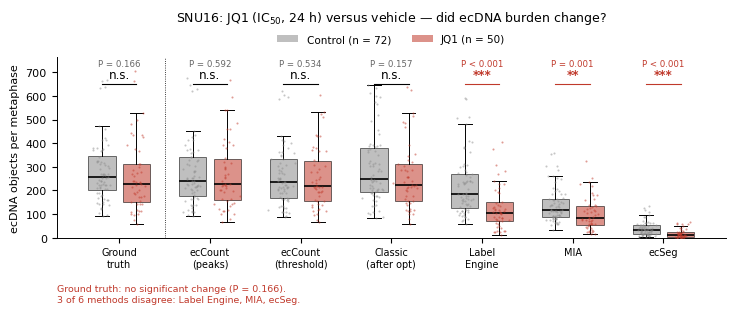

In [21]:
_, CL_A, TRE_A, CTL_A, _ = next(p for p in PAIRS if p[0] == HEAD)
sa = res[(res.subset == "all benchmark drug images") &
         (res.contrast == HEAD)].set_index("model")
sub_ = allm[allm.cell_line == CL_A]
nC, nT = int(sa.n_control.iloc[0]), int(sa.n_treated.iloc[0])
ymax = sub_[sub_.cond.isin(TRE_A + CTL_A)].pred_count.quantile(0.98)
YS = ymax * 1.02
jit = np.random.default_rng(SEED)

fig, ax = plt.subplots(figsize=(7.4, 3.4))
for pos, mod in enumerate(ORDER):
    d = sub_[sub_.model == mod]
    Cv = d[d.cond.isin(CTL_A)].pred_count.to_numpy()
    Tv = d[d.cond.isin(TRE_A)].pred_count.to_numpy()
    for vals, col, off in [(Cv, CTRL, -0.19), (Tv, TRT, 0.19)]:
        bp = ax.boxplot([vals], positions=[pos + off], widths=0.30, patch_artist=True,
                        showfliers=False, medianprops=dict(color="black", lw=1.2),
                        whiskerprops=dict(lw=0.7), capprops=dict(lw=0.7))
        bp["boxes"][0].set_facecolor(col); bp["boxes"][0].set_alpha(.55)
        bp["boxes"][0].set_linewidth(.7)
        ax.scatter(jit.normal(pos + off, .045, vals.size), vals, s=2.2,
                   color=col, alpha=.5, lw=0, zorder=3)
    p = float(sa.loc[mod, "p_mwu"]); wrong = p < .05
    star = "n.s." if p >= .05 else ("***" if p < .001 else ("**" if p < .01 else "*"))
    c = "#c0392b" if wrong else "black"
    ax.plot([pos - .19, pos + .19], [YS] * 2, lw=.8, color=c)
    ax.text(pos, YS + ymax * .02, star, ha="center", va="bottom", fontsize=8.5,
            color=c, fontweight="bold" if wrong else "normal")
    ax.text(pos, YS + ymax * .11, "P < 0.001" if p < .001 else f"P = {p:.3f}",
            ha="center", va="bottom", fontsize=6.2, color=c if wrong else "#666666")

ax.axvline(0.5, color="k", lw=.6, ls=":")
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels([SHORT[m] for m in ORDER], fontsize=7)
ax.set_ylabel("ecDNA objects per metaphase"); ax.set_ylim(0, ymax * 1.20)
ax.legend(handles=[Patch(facecolor=CTRL, alpha=.55, label=f"Control (n = {nC})"),
                   Patch(facecolor=TRT, alpha=.55, label=f"JQ1 (n = {nT})")],
          frameon=False, fontsize=7.5, loc="lower center",
          bbox_to_anchor=(0.5, 1.02), ncol=2)
ax.set_title(f"{CL_A}: JQ1 (IC$_{{50}}$, 24 h) versus vehicle — did ecDNA burden change?",
             fontsize=9, pad=26)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
dis = [m for m in MODELS if bool(sa.loc[m, "sig_005"]) != bool(sa.loc["Ground truth", "sig_005"])]
ax.text(0, -0.26, f"Gold standard: no significant change "
        f"(P = {float(sa.loc['Ground truth','p_mwu']):.3f}).\n"
        f"{len(dis)} of {len(MODELS)} methods disagree: {', '.join(dis)}.",
        transform=ax.transAxes, fontsize=6.8, color="#c0392b", va="top")
plt.tight_layout(); save(fig, "fig7a_headline_contrast"); plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7b_effect_recovery.[png|svg]


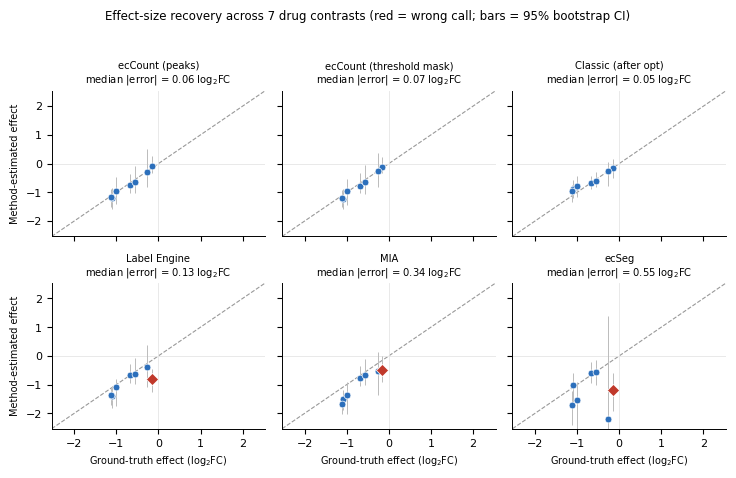

In [22]:
r = res[(res.subset == "all benchmark drug images") & (res.model != "Ground truth")]
fig, axes = plt.subplots(2, 3, figsize=(7.4, 4.8), sharex=True, sharey=True)
lim = max(r.log2_fc.abs().max(), r.gt_log2fc.abs().max()) * 1.15
for ax, mod in zip(axes.ravel(), MODELS):
    d = r[r.model == mod]; bad = (~d.sig_agrees) | (~d.direction_agrees)
    ax.axline((0, 0), slope=1, color="#999999", lw=.8, ls="--", zorder=0)
    ax.axhline(0, color="#e5e5e5", lw=.6); ax.axvline(0, color="#e5e5e5", lw=.6)
    ax.errorbar(d.gt_log2fc, d.log2_fc,
                yerr=[d.log2_fc - d.log2_fc_lo, d.log2_fc_hi - d.log2_fc],
                fmt="none", ecolor="#bbbbbb", elinewidth=.7, zorder=2)
    ax.scatter(d.gt_log2fc[~bad], d.log2_fc[~bad], s=24, color="#2c6fbb",
               lw=.5, edgecolor="white", zorder=3)
    ax.scatter(d.gt_log2fc[bad], d.log2_fc[bad], s=38, color="#c0392b",
               marker="D", lw=.5, edgecolor="white", zorder=4)
    ax.set_title(f"{mod}\nmedian |error| = {np.median(np.abs(d.log2fc_error)):.2f} log$_2$FC",
                 fontsize=7.2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
for ax in axes[1]:
    ax.set_xlabel("Gold-standard effect (log$_2$FC)", fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("Method-estimated effect", fontsize=7)
fig.suptitle(f"Effect-size recovery across {r.contrast.nunique()} drug contrasts "
             "(red = wrong call; bars = 95% bootstrap CI)", fontsize=8.5)
plt.tight_layout(rect=[0, 0, 1, .95]); save(fig, "fig7b_effect_recovery"); plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7c_recovery_vs_density.[png|svg]


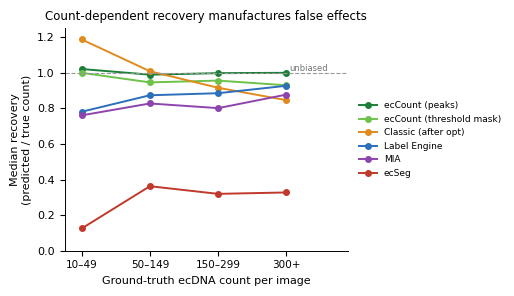

In [23]:
fig, ax = plt.subplots(figsize=(5.2, 3.0))
for mod in MODELS:
    ax.plot(range(len(recov)), recov[mod], "o-", ms=4, lw=1.4, color=COL[mod], label=mod)
ax.axhline(1, color="#999999", ls="--", lw=.8)
ax.text(len(recov) - .95, 1.01, "unbiased", fontsize=6, color="#777777")
ax.set_xticks(range(len(recov))); ax.set_xticklabels(recov.index, fontsize=7.5)
ax.set_xlabel("Gold-standard ecDNA count per image")
ax.set_ylabel("Median recovery\n(predicted / gold-standard count)")
ax.set_ylim(0, 1.25); ax.set_xlim(-.25, len(recov) - .1)
ax.legend(frameon=False, fontsize=6.5, loc="center left", bbox_to_anchor=(1.01, .5))
ax.set_title("Count-dependent recovery manufactures false effects", fontsize=8.5)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); save(fig, "fig7c_recovery_vs_density"); plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7d_agreement_matrix.[png|svg]


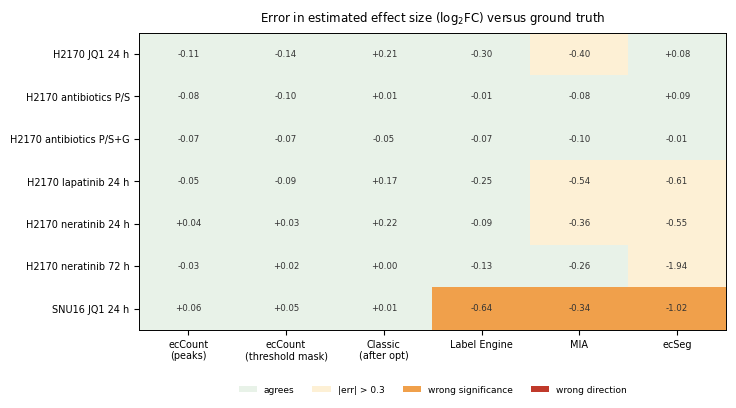

In [24]:
r = res[(res.subset == "all benchmark drug images") & (res.model != "Ground truth")].copy()
r["code"] = np.where(~r.direction_agrees, 3,
             np.where(~r.sig_agrees, 2, np.where(r.log2fc_error.abs() > .3, 1, 0)))
cm = r.pivot_table(index="contrast", columns="model", values="code")[MODELS]
er = r.pivot_table(index="contrast", columns="model", values="log2fc_error")[MODELS]

fig, ax = plt.subplots(figsize=(7.4, .38 * len(cm) + 1.5))
ax.imshow(cm.to_numpy(), cmap=ListedColormap(["#e8f2e8", "#fdf0d5", "#f0a04b", "#c0392b"]),
          vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([m.replace(" (", "\n(") for m in MODELS], fontsize=7)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index, fontsize=7)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{er.to_numpy()[i, j]:+.2f}", ha="center", va="center",
                fontsize=6.2, color="white" if cm.to_numpy()[i, j] == 3 else "#333333")
ax.set_title("Error in estimated effect size (log$_2$FC) versus gold standard",
             fontsize=8.5, pad=8)
ax.legend(handles=[Patch(fc="#e8f2e8", label="agrees"), Patch(fc="#fdf0d5", label="|err| > 0.3"),
                   Patch(fc="#f0a04b", label="wrong significance"), Patch(fc="#c0392b", label="wrong direction")],
          frameon=False, fontsize=6.5, loc="upper center", bbox_to_anchor=(.5, -.16), ncol=4)
plt.tight_layout(); save(fig, "fig7d_agreement_matrix"); plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7e_mae_bias_heatmaps.[png|svg]


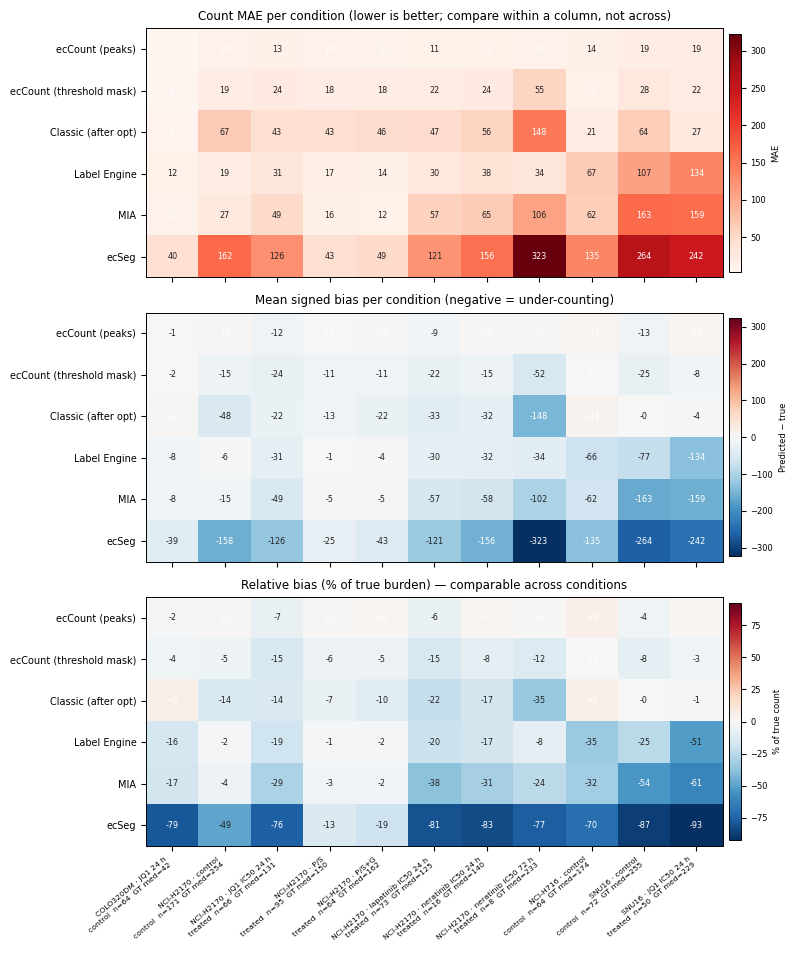

In [25]:
from matplotlib.colors import TwoSlopeNorm

def heat(ax, mat, title, cmap, norm=None, fmt="{:.0f}", cbar_label=""):
    vals = mat.to_numpy(dtype=float)

    im = ax.imshow(
        vals,
        cmap=cmap,
        norm=norm,
        aspect="auto"
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(
        mat.columns,
        fontsize=6,
        rotation=40,
        ha="right"
    )

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=7)

    # Thresholds used only to choose black versus white annotation text
    finite_vals = vals[np.isfinite(vals)]

    if finite_vals.size:
        lo, hi = np.nanpercentile(finite_vals, [15, 85])
    else:
        lo, hi = np.nan, np.nan

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = vals[i, j]

            if np.isfinite(value):
                use_white = value < lo or value > hi

                ax.text(
                    j,
                    i,
                    fmt.format(value),
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color="white" if use_white else "#222222"
                )

    ax.set_title(title, fontsize=8.5, pad=6)

    colorbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.02,
        pad=0.01
    )
    colorbar.ax.tick_params(labelsize=6)
    colorbar.set_label(cbar_label, fontsize=6)

    return im


def symmetric_zero_norm(mat):
    """Create a zero-centered symmetric color scale for signed values."""
    vals = mat.to_numpy(dtype=float)
    finite_vals = vals[np.isfinite(vals)]

    if finite_vals.size == 0:
        limit = 1.0
    else:
        limit = np.nanmax(np.abs(finite_vals))

        if not np.isfinite(limit) or limit == 0:
            limit = 1.0

    return TwoSlopeNorm(
        vmin=-limit,
        vcenter=0,
        vmax=limit
    )


# Remove duplicate labels while preserving their original order
MODELS = list(dict.fromkeys(MODELS))
GROUPS = list(dict.fromkeys(GROUPS))


# -------------------------------------------------------------------------
# Create model-by-condition matrices
# -------------------------------------------------------------------------

MAE = (
    err.pivot_table(
        index="model",
        columns="group_label",
        values="count_MAE"
    )
    .reindex(index=MODELS, columns=GROUPS)
)

BIAS = (
    err.pivot_table(
        index="model",
        columns="group_label",
        values="count_bias"
    )
    .reindex(index=MODELS, columns=GROUPS)
)

RELB = (
    err.pivot_table(
        index="model",
        columns="group_label",
        values="relative_bias_pct"
    )
    .reindex(index=MODELS, columns=GROUPS)
)


# Save heatmap source tables
for matrix, name in [
    (MAE, "mae"),
    (BIAS, "bias"),
    (RELB, "relative_bias_pct"),
]:
    matrix.to_csv(TABDIR / f"heatmap_{name}_by_condition.csv")


# -------------------------------------------------------------------------
# Calculate gold-standard burden and sample size for each condition
# -------------------------------------------------------------------------

ground_truth = allm.loc[
    allm["model"].eq("Ground truth")
].copy()

gtmed = (
    ground_truth
    .groupby("group_label")["gt_count"]
    .median()
    .reindex(GROUPS)
)

narm = (
    ground_truth
    .groupby("group_label")
    .agg(
        n=("uid", "size"),
        arm=("arm", "first")
    )
    .reindex(GROUPS)
)


# Create detailed labels for the bottom heatmap
xlabels = []

for group in GROUPS:
    arm_value = narm.loc[group, "arm"]
    n_value = narm.loc[group, "n"]
    gt_value = gtmed.loc[group]

    arm_text = "NA" if pd.isna(arm_value) else str(arm_value)
    n_text = "NA" if pd.isna(n_value) else f"{int(n_value)}"
    gt_text = "NA" if pd.isna(gt_value) else f"{gt_value:.0f}"

    xlabels.append(
        f"{group}\n"
        f"{arm_text}  n={n_text}  GS med={gt_text}"
    )


# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(max(8, 0.62 * len(GROUPS)), 9.6)
)

heat(
    axes[0],
    MAE,
    title=(
        "Count MAE per condition "
        "(lower is better; compare within a column, not across)"
    ),
    cmap="Reds",
    fmt="{:.0f}",
    cbar_label="MAE"
)

heat(
    axes[1],
    BIAS,
    title="Mean signed bias per condition (negative = under-counting)",
    cmap="RdBu_r",
    norm=symmetric_zero_norm(BIAS),
    fmt="{:+.0f}",
    cbar_label="Predicted − true"
)

heat(
    axes[2],
    RELB,
    title="Relative bias (% of gold-standard burden) — comparable across conditions",
    cmap="RdBu_r",
    norm=symmetric_zero_norm(RELB),
    fmt="{:+.0f}",
    cbar_label="% of gold-standard count"
)


# Only display detailed condition labels on the bottom panel
for ax in axes[:2]:
    ax.tick_params(axis="x", labelbottom=False)

axes[2].set_xticks(np.arange(len(GROUPS)))
axes[2].set_xticklabels(
    xlabels,
    fontsize=5.6,
    rotation=40,
    ha="right"
)

plt.tight_layout()

save(fig, "fig7e_mae_bias_heatmaps")

plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7f_bias_significance.[png|svg]


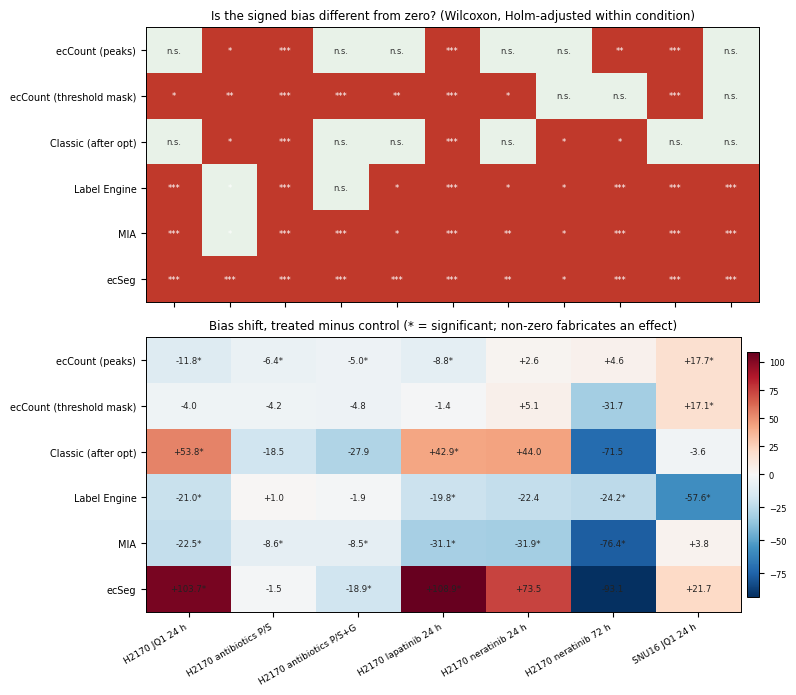

In [26]:
BS = sig.pivot_table(index="model", columns="group_label",
                     values="bias_significant").reindex(MODELS)[GROUPS]
QB = sig.pivot_table(index="model", columns="group_label",
                     values="q_bias_vs_zero").reindex(MODELS)[GROUPS]

fig, axes = plt.subplots(2, 1, figsize=(max(8, .62 * len(GROUPS)), 7.0))

ax = axes[0]
ax.imshow(BS.astype(float).to_numpy(), cmap=ListedColormap(["#e8f2e8", "#c0392b"]),
          vmin=0, vmax=1, aspect="auto")
for i in range(BS.shape[0]):
    for j in range(BS.shape[1]):
        q = QB.to_numpy()[i, j]
        s_ = "n.s." if not BS.to_numpy()[i, j] else ("***" if q < .001 else ("**" if q < .01 else "*"))
        ax.text(j, i, s_, ha="center", va="center", fontsize=6,
                color="white" if BS.to_numpy()[i, j] else "#333333")
ax.set_xticks(range(len(GROUPS))); ax.set_xticklabels([])
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS, fontsize=7)
ax.set_title("Is the signed bias different from zero? (Wilcoxon, Holm-adjusted within condition)",
             fontsize=8.5)

ax = axes[1]
SH = shift.pivot_table(index="model", columns="contrast", values="bias_shift").reindex(MODELS)
SS = shift.pivot_table(index="model", columns="contrast", values="shift_significant").reindex(MODELS)
im = ax.imshow(SH.to_numpy(), cmap="RdBu_r",
               norm=TwoSlopeNorm(vcenter=0,
                                 vmin=min(-1, np.nanmin(SH.to_numpy())),
                                 vmax=max(1, np.nanmax(SH.to_numpy()))), aspect="auto")
for i in range(SH.shape[0]):
    for j in range(SH.shape[1]):
        v = SH.to_numpy()[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:+.1f}" + ("*" if SS.to_numpy()[i, j] else ""),
                    ha="center", va="center", fontsize=6.2, color="#222222")
ax.set_xticks(range(SH.shape[1]))
ax.set_xticklabels(SH.columns, fontsize=6.5, rotation=30, ha="right")
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS, fontsize=7)
ax.set_title("Bias shift, treated minus control (* = significant; non-zero fabricates an effect)",
             fontsize=8.5)
plt.colorbar(im, ax=ax, fraction=.02, pad=.01).ax.tick_params(labelsize=6)
plt.tight_layout(); save(fig, "fig7f_bias_significance"); plt.show()

In [27]:
allm.to_csv(TABDIR / "source_per_image_counts_drug_conditions.csv", index=False)
pd.DataFrame([{"token": k, **v} for k, v in CONDITION_MAP.items()]).to_csv(
    TABDIR / "condition_map.csv", index=False)

rows = [dict(filename=p.name, file_type=p.suffix.lstrip("."),
             size_kb=round(p.stat().st_size / 1024, 1), path=str(p))
        for p in sorted(list(FIGDIR.iterdir()) + list(TABDIR.iterdir())) if p.is_file()]
pd.DataFrame(rows).to_csv(OUTDIR / "biology_analysis_output_manifest.csv", index=False)
print(pd.DataFrame(rows).to_string(index=False))

print(f"\nProvenance\n  source   : {PIM_PATH}\n  matching : OR, d_max=20 px, IoU_min=0.1"
      f"\n  scope    : {INCLUDE_EXPERIMENTS}, FACS and CAR-T excluded"
      f"\n  images   : {allm[allm.model=='Ground truth'].uid.nunique()}"
      f"\n  groups   : {len(GROUPS)}   contrasts: {len(PAIRS)}"
      f"\n  status   : EXPLORATORY — not frozen")

                                     filename file_type  size_kb                                                                                                        path
                  fig7a_headline_contrast.png       png    263.6                  /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7a_headline_contrast.png
                  fig7a_headline_contrast.svg       svg    131.5                  /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7a_headline_contrast.svg
         fig7a_snu16_jq1_burden_by_method.png       png    265.1         /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7a_snu16_jq1_burden_by_method.png
         fig7a_snu16_jq1_burden_by_method.svg       svg    125.4         /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig7a_snu16_jq1_burden_by_method.svg
                    fig7b_effect_recovery.png       png    260.6                    /proj/brunk_ecdna_cv_project/Poorya/Notebooks-rerun

# Step 2 — ROI model validation

Does River's predicted ROI mask work as a drop-in replacement for the manual one?

Three sub-questions:
  2A  pixel agreement            — Dice, IoU, how much of the metaphase is kept
  2B  ecDNA object loss          — annotated ecDNA that fall outside the predicted ROI
  2C  cost to ecCount            — F1 and counts, manual ROI vs predicted ROI

All numbers come from CSVs already computed on the cluster
(compare_roi_masks.py, roi_ecdna_loss.py, prepare_river_roi_run.py) plus the two
frozen benchmark runs. No image processing happens in this notebook.

DISCLOSURE carried through every table and figure below:
River's ROI model was trained on the 800-image training split. Metrics over all
1,145 benchmark images are inflated — 70% of them are training data. The honest
figure is val+test (345 images). Both are reported; val+test is what goes in the
paper (Supplementary Methods §11). the paper.

In [28]:
RIVER_RUN    = PROJ / "release" / "river_roi_run"
ROI_VAL      = PROJ / "release" / "roi_validation"
PRED_ROI_DIR = PROJ.parent / "River" / "output" / "all"

AGREE = ROI_VAL / "roi_agreement.csv"
LOSS  = ROI_VAL / "roi_ecdna_loss.csv"
PREP  = RIVER_RUN / "preparation_report.csv"

MAN_METRICS   = PROJ / "release" / "frozen_results" / "or_matching" / "per_image_metrics.csv"
RIVER_METRICS = RIVER_RUN / "frozen_results" / "or_matching" / "per_image_metrics.csv"

for p in (AGREE, LOSS, PREP, MAN_METRICS, RIVER_METRICS):
    assert p.exists(), f"MISSING: {p}"
    assert "and_matching" not in {q.lower() for q in p.parts}, f"AND policy: {p}"
    print(f"ok  {sum(1 for _ in open(p)) - 1:>6} rows  {p.relative_to(PROJ)}")

print(f"\npredicted ROI masks: {len(list(PRED_ROI_DIR.iterdir())):,}  {PRED_ROI_DIR}")

ok    1145 rows  release/roi_validation/roi_agreement.csv
ok    1145 rows  release/roi_validation/roi_ecdna_loss.csv
ok    2986 rows  release/river_roi_run/preparation_report.csv
ok    6870 rows  release/frozen_results/or_matching/per_image_metrics.csv
ok    2290 rows  release/river_roi_run/frozen_results/or_matching/per_image_metrics.csv

predicted ROI masks: 2,986  /proj/brunk_ecdna_cv_project/Poorya/River/output/all


In [29]:
agree = pd.read_csv(AGREE)
loss  = pd.read_csv(LOSS)
prep  = pd.read_csv(PREP)

roi = (agree
       .merge(loss.drop(columns=["split"], errors="ignore"),
              on="unique_id", how="inner", validate="one_to_one")
       .merge(prep[["unique_id", "cell_line", "status", "kept_frac"]],
              on="unique_id", how="left", validate="one_to_one")
       .rename(columns={"unique_id": "uid",
                        "dice": "roi_dice", "iou": "roi_iou",
                        "manual_kept": "roi_recall",
                        "pred_purity": "roi_precision"}))

roi["ecdna_retention"] = np.where(roi.n_in_manual > 0,
                                  roi.n_in_pred / roi.n_in_manual, np.nan)
roi["ecdna_lost"] = roi.n_lost
roi["subset"] = np.where(roi.split == "train",
                         "train (SEEN by ROI model)", "val+test (held out)")

bench_ids = set(pim.uid.unique())
assert set(roi.uid) == bench_ids, (
    f"ROI validation covers {len(set(roi.uid))} UIDs, benchmark has {len(bench_ids)}"
)

roi.to_csv(TABDIR / "roi_validation_per_image.csv", index=False)
print(f"{len(roi):,} benchmark images")
print(roi.subset.value_counts().to_string())
print("\nprep status:", roi.status.value_counts().to_dict())
print("empty predicted ROI:", int(roi.pred_empty.sum()),
      "| empty manual ROI:", int(roi.manual_empty.sum()))

1,145 benchmark images
subset
train (SEEN by ROI model)    800
val+test (held out)          345

prep status: {'ok': 1145}
empty predicted ROI: 0 | empty manual ROI: 0


In [30]:
AGG = dict(
    n_images=("uid", "size"),
    dice_median=("roi_dice", "median"),      dice_mean=("roi_dice", "mean"),
    dice_p10=("roi_dice", lambda s: s.quantile(.10)),
    iou_median=("roi_iou", "median"),
    recall_median=("roi_recall", "median"),  # fraction of manual ROI kept
    precision_median=("roi_precision", "median"),
    area_ratio_median=("area_ratio", "median"),
    retention_median=("ecdna_retention", "median"),
    retention_mean=("ecdna_retention", "mean"),
    retention_p10=("ecdna_retention", lambda s: s.quantile(.10)),
    ecdna_in_manual=("n_in_manual", "sum"),
    ecdna_in_pred=("n_in_pred", "sum"),
    ecdna_lost_total=("ecdna_lost", "sum"),
    ecdna_gained_total=("n_gained", "sum"),
)

def finish(t):
    t["pct_ecdna_lost"] = 100 * t.ecdna_lost_total / t.ecdna_in_manual
    t["net_delta_per_image"] = (t.ecdna_in_pred - t.ecdna_in_manual) / t.n_images
    return t.round(4)

overall  = finish(roi.assign(_="all 1,145 (INFLATED)").groupby("_").agg(**AGG))
by_sub   = finish(roi.groupby("subset").agg(**AGG))
by_cell  = finish(roi.groupby(["subset", "cell_line"]).agg(**AGG))

print("=== ALL 1,145 — inflated, 70% is ROI-model training data ===")
print(overall.T.to_string())
print("\n=== BY SUBSET — val+test is the honest figure ===")
print(by_sub.T.to_string())
print("\n=== BY CELL LINE ===")
print(by_cell[["n_images", "dice_median", "retention_median",
               "pct_ecdna_lost"]].to_string())

pd.concat([overall, by_sub]).to_csv(TABDIR / "roi_validation_summary.csv")
by_cell.to_csv(TABDIR / "roi_validation_by_cell_line.csv")

=== ALL 1,145 — inflated, 70% is ROI-model training data ===
_                    all 1,145 (INFLATED)
n_images                        1145.0000
dice_median                        0.9017
dice_mean                          0.8783
dice_p10                           0.7943
iou_median                         0.8210
recall_median                      0.9263
precision_median                   0.8974
area_ratio_median                  1.0359
retention_median                   0.9974
retention_mean                     0.9848
retention_p10                      0.9609
ecdna_in_manual               230589.0000
ecdna_in_pred                 227158.0000
ecdna_lost_total                3661.0000
ecdna_gained_total               230.0000
pct_ecdna_lost                     1.5877
net_delta_per_image               -2.9965

=== BY SUBSET — val+test is the honest figure ===
subset               train (SEEN by ROI model)  val+test (held out)
n_images                              800.0000             345.0

In [31]:
held = roi[roi.subset.str.startswith("val+test")]
pct  = 100 * held.ecdna_lost.sum() / held.n_in_manual.sum()

print(f"HELD-OUT (val+test, n = {len(held)} images)")
print(f"  ROI Dice          median {held.roi_dice.median():.3f}   "
      f"mean {held.roi_dice.mean():.3f}   p10 {held.roi_dice.quantile(.10):.3f}")
print(f"  ROI IoU           median {held.roi_iou.median():.3f}")
print(f"  metaphase kept    median {held.roi_recall.median():.3f}")
print(f"  ecDNA retention   median {held.ecdna_retention.median():.3f}   "
      f"p10 {held.ecdna_retention.quantile(.10):.3f}")
print(f"  ecDNA lost        {int(held.ecdna_lost.sum()):,} of "
      f"{int(held.n_in_manual.sum()):,}   ({pct:.2f}%)")
print(f"  ecDNA gained      {int(held.n_gained.sum()):,}  (outside manual ROI)")
print(f"  net count shift   {(held.n_in_pred - held.n_in_manual).mean():+.2f} "
      f"ecDNA/image   [ecCount's own MAE = 13.1, bias = +0.4]")
print(f"\n  images with zero loss    {int((held.ecdna_lost == 0).sum())} "
      f"/ {len(held)}  ({100*(held.ecdna_lost == 0).mean():.1f}%)")
print(f"  images losing >5%        {int((held.pct_lost > 5).sum())}")
print(f"  images with Dice < 0.80  {int((held.roi_dice < 0.80).sum())}")

HELD-OUT (val+test, n = 345 images)
  ROI Dice          median 0.888   mean 0.857   p10 0.752
  ROI IoU           median 0.799
  metaphase kept    median 0.925
  ecDNA retention   median 0.995   p10 0.943
  ecDNA lost        1,716 of 66,732   (2.57%)
  ecDNA gained      22  (outside manual ROI)
  net count shift   -4.91 ecDNA/image   [ecCount's own MAE = 13.1, bias = +0.4]

  images with zero loss    155 / 345  (44.9%)
  images losing >5%        38
  images with Dice < 0.80  57


In [32]:
BINS, LABS = [0, 9, 49, 149, 299, np.inf], ["1–9", "10–49", "50–149", "150–299", "300+"]

def burden_table(d, name):
    t = (d.assign(bin=pd.cut(d.n_in_manual, BINS, labels=LABS))
           .groupby("bin", observed=True)
           .agg(n_images=("uid", "size"),
                mean_lost=("ecdna_lost", "mean"),
                median_retention=("ecdna_retention", "median"),
                lost_sum=("ecdna_lost", "sum"),
                manual_sum=("n_in_manual", "sum")))
    t["pct_lost"] = 100 * t.lost_sum / t.manual_sum
    print(f"\n{name}")
    print(t[["n_images", "mean_lost", "pct_lost", "median_retention"]].round(3).to_string())
    return t

t_held = burden_table(held, "HELD-OUT (val+test) — the honest table")
t_all  = burden_table(roi,  "ALL 1,145 (inflated)")
t_held.to_csv(TABDIR / "roi_loss_by_burden_heldout.csv")

r = np.corrcoef(held.n_in_manual, held.ecdna_lost)[0, 1]
spread = t_held.pct_lost.max() - t_held.pct_lost.min()
print(f"\nPearson r (burden vs ecDNA lost) = {r:+.3f}")
print(f"pct_lost spread across bins      = {spread:.2f} percentage points")
print("\nFLAT pct_lost  -> loss cancels in any group comparison; ROIs are usable.")
print("RISING pct_lost -> reintroduces the burden-dependent underestimation the")
print("                   paper argues against. Would undermine our own result.")


HELD-OUT (val+test) — the honest table
         n_images  mean_lost  pct_lost  median_retention
bin                                                     
1–9             3      0.333     5.882             1.000
10–49          25      1.040     2.971             1.000
50–149        129      3.465     3.612             1.000
150–299       125      6.048     2.945             0.991
300+           63      7.714     1.748             0.991

ALL 1,145 (inflated)
         n_images  mean_lost  pct_lost  median_retention
bin                                                     
1–9             7      0.143     3.030             1.000
10–49          79      0.532     1.564             1.000
50–149        445      1.978     1.994             1.000
150–299       403      4.042     1.888             0.994
300+          211      5.256     1.138             0.996

Pearson r (burden vs ecDNA lost) = +0.215
pct_lost spread across bins      = 4.13 percentage points

FLAT pct_lost  -> loss cancels in any 

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig8a_roi_validation_overview.[png|svg]


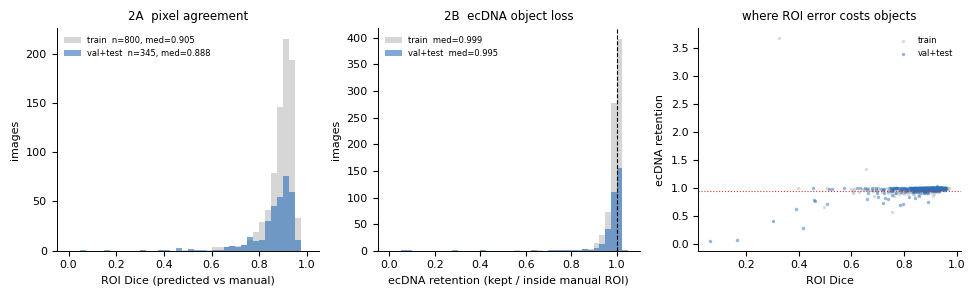

In [33]:
subs = ["train (SEEN by ROI model)", "val+test (held out)"]
sc = {subs[0]: "#bbbbbb", subs[1]: "#2c6fbb"}

fig, axes = plt.subplots(1, 3, figsize=(9.8, 3.0))

ax = axes[0]
for s in subs:
    d = roi.loc[roi.subset == s, "roi_dice"].dropna()
    ax.hist(d, bins=np.linspace(0, 1, 41), alpha=0.6, color=sc[s],
            label=f"{s.split(' (')[0]}  n={len(d)}, med={d.median():.3f}")
ax.set_xlabel("ROI Dice (predicted vs manual)"); ax.set_ylabel("images")
ax.legend(frameon=False, fontsize=6); ax.set_title("2A  pixel agreement", fontsize=8.5)

ax = axes[1]
for s in subs:
    d = roi.loc[roi.subset == s, "ecdna_retention"].dropna()
    ax.hist(d, bins=np.linspace(0, 1.05, 43), alpha=0.6, color=sc[s],
            label=f"{s.split(' (')[0]}  med={d.median():.3f}")
ax.axvline(1.0, color="k", ls="--", lw=0.8)
ax.set_xlabel("ecDNA retention (kept / inside manual ROI)"); ax.set_ylabel("images")
ax.legend(frameon=False, fontsize=6); ax.set_title("2B  ecDNA object loss", fontsize=8.5)

ax = axes[2]
for s in subs:
    d = roi[roi.subset == s]
    ax.scatter(d.roi_dice, d.ecdna_retention, s=6, alpha=0.5, lw=0,
               color=sc[s], label=s.split(" (")[0])
ax.axhline(0.95, color="#c0392b", ls=":", lw=0.8)
ax.set_xlabel("ROI Dice"); ax.set_ylabel("ecDNA retention")
ax.legend(frameon=False, fontsize=6)
ax.set_title("where ROI error costs objects", fontsize=8.5)

for a in axes:
    for s_ in ("top", "right"):
        a.spines[s_].set_visible(False)
plt.tight_layout()
save(fig, "fig8a_roi_validation_overview")
plt.show()

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig8b_roi_loss_by_burden.[png|svg]


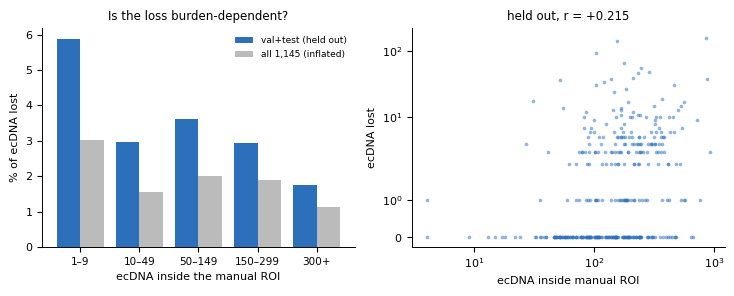

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))

ax = axes[0]
x = np.arange(len(t_held))
ax.bar(x - 0.2, t_held.pct_lost, width=0.4, color="#2c6fbb", label="val+test (held out)")
ax.bar(x + 0.2, t_all.reindex(t_held.index).pct_lost, width=0.4,
       color="#bbbbbb", label="all 1,145 (inflated)")
ax.set_xticks(x); ax.set_xticklabels(t_held.index, fontsize=7.5)
ax.set_xlabel("ecDNA inside the manual ROI"); ax.set_ylabel("% of ecDNA lost")
ax.legend(frameon=False, fontsize=6.5)
ax.set_title("Is the loss burden-dependent?", fontsize=8.5)

ax = axes[1]
ax.scatter(held.n_in_manual, held.ecdna_lost, s=7, alpha=0.5, lw=0, color="#2c6fbb")
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_xlabel("ecDNA inside manual ROI"); ax.set_ylabel("ecDNA lost")
ax.set_title(f"held out, r = {r:+.3f}", fontsize=8.5)

for a in axes:
    for s_ in ("top", "right"):
        a.spines[s_].set_visible(False)
plt.tight_layout()
save(fig, "fig8b_roi_loss_by_burden")
plt.show()

In [35]:
worst = (held.nsmallest(15, "ecdna_retention")
             [["uid", "cell_line", "split", "roi_dice", "roi_recall",
               "roi_precision", "area_ratio", "n_in_manual", "ecdna_lost",
               "pct_lost", "ecdna_retention"]])
worst.to_csv(TABDIR / "roi_worst_cases_heldout.csv", index=False)
print(worst.round(3).to_string(index=False))
print("\nby cell line, images with retention < 0.90 (held out):")
print(held[held.ecdna_retention < 0.90].cell_line.value_counts().to_string())

                                 uid cell_line split  roi_dice  roi_recall  roi_precision  area_ratio  n_in_manual  ecdna_lost  pct_lost  ecdna_retention
     ncih2170_antibiotics_ps_g_107_a NCI-H2170  test     0.062       0.079          0.052       1.530          103          96    93.204            0.068
        ncih2170_antibiotics_ps_34_c NCI-H2170   val     0.164       0.190          0.144       1.324          156         144    92.308            0.077
        ncih2170_antibiotics_ps_29_b NCI-H2170   val     0.416       0.526          0.344       1.530           52          37    71.154            0.288
    colo320dm_qpcr_jq1_24h_ctrl_87_a COLO320DM  test     0.302       0.445          0.228       1.948           31          18    58.065            0.419
                     snu16_jc_ctrl_9     SNU16   val     0.388       0.241          1.000       0.241          179          67    37.430            0.626
 ncih2170_facs_fish_0723_low_her2_12 NCI-H2170   val     0.783       0.680  

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig8d_roi_worst_cases.[png|svg]


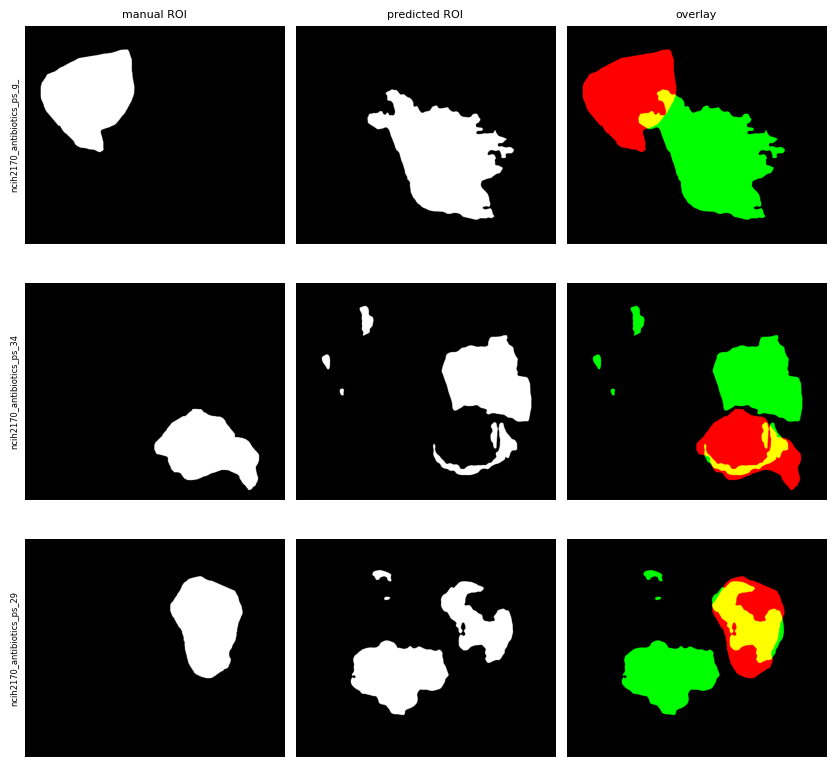

In [41]:
# ROI paths. Move these two lines into cell 1 with the other constants before
# the notebook is archived; they are here so this cell is self-contained.
META = PROJ / "release/manifests/metadata.csv"
PRED_ROI_DIR = Path("/proj/brunk_ecdna_cv_project/Poorya/River/output/all")
assert META.is_file(), f"not found: {META}"
assert PRED_ROI_DIR.is_dir(), f"not found: {PRED_ROI_DIR}"

import imageio.v3 as iio

# River's output holds mixed formats; resolve the extension rather than
# assuming .png.
_ROI_IDX = {p.stem: p for p in sorted(PRED_ROI_DIR.iterdir())
            if p.suffix.lower() in {".png", ".tif", ".tiff"}}


def _b(p):
    a = iio.imread(str(p))
    # max across channels, matching to_binary() in prepare_river_roi_run.py.
    # Channel 0 alone returns a blank mask, silently, if the mask went elsewhere.
    return (a.max(axis=2) if a.ndim == 3 else a) > 0


meta_idx = pd.read_csv(META).set_index("unique_id")
assert "roi_fullpath" in meta_idx.columns, "no roi_fullpath column in metadata.csv"

picks = worst.uid.head(3).tolist()
# roi_fullpath exists only for the 1,145 benchmark images; extension images have
# no manual ROI to compare against.
bad = [u for u in picks if u not in meta_idx.index or u not in _ROI_IDX]
assert not bad, f"no manual ROI or no predicted ROI for: {bad}"

fig, axes = plt.subplots(len(picks), 3, figsize=(8.4, 2.7 * len(picks)))
axes = np.atleast_2d(axes)
for i, uid in enumerate(picks):
    man = _b(meta_idx.loc[uid, "roi_fullpath"])
    pred = _b(_ROI_IDX[uid])
    if man.shape != pred.shape:
        raise ValueError(f"{uid}: manual {man.shape} vs predicted {pred.shape}")
    axes[i, 0].imshow(man, cmap="gray")
    axes[i, 0].set_ylabel(uid[:26], fontsize=6)
    axes[i, 1].imshow(pred, cmap="gray")
    ov = np.zeros(man.shape + (3,), np.uint8)
    ov[..., 0] = man * 255      # red    = manual only
    ov[..., 1] = pred * 255     # green  = predicted only
    axes[i, 2].imshow(ov)       # yellow = agreement
    for j, t in enumerate(["manual ROI", "predicted ROI", "overlay"]):
        if i == 0:
            axes[i, j].set_title(t, fontsize=8)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
    del man, pred, ov
plt.tight_layout()
save(fig, "fig8d_roi_worst_cases")
plt.show()

In [37]:
NAME_MAP = {"eccount_peaks": "ecCount (peaks)",
            "eccount_mask": "ecCount (threshold mask)",
            "eccount_threshold": "ecCount (threshold mask)"}
EC = ["ecCount (peaks)", "ecCount (threshold mask)"]

man_m = pd.read_csv(MAN_METRICS)
riv_m = pd.read_csv(RIVER_METRICS)
riv_m["model"] = riv_m.model.replace(NAME_MAP)
man_m["model"] = man_m.model.replace(NAME_MAP)

print("manual-ROI run :", sorted(man_m.model.unique()))
print("river-ROI run  :", sorted(riv_m.model.unique()))
assert set(EC) <= set(riv_m.model.unique()) and set(EC) <= set(man_m.model.unique())

KEEP = ["uid", "model", "split", "cell_line", "obj_f1", "obj_precision",
        "obj_recall", "pred_count", "gt_count", "pix_dice"]
sfx = lambda df, s: df[KEEP].rename(
    columns={c: f"{c}_{s}" for c in KEEP if c not in ("uid", "model")})

cmp = sfx(man_m[man_m.model.isin(EC)], "manual").merge(
      sfx(riv_m[riv_m.model.isin(EC)], "pred"),
      on=["uid", "model"], validate="one_to_one")

cmp["split"]  = cmp.split_manual
cmp["subset"] = np.where(cmp.split == "train",
                         "train (SEEN by ROI model)", "val+test (held out)")
cmp["delta_obj_f1"]  = cmp.obj_f1_pred - cmp.obj_f1_manual
cmp["delta_pred_ct"] = cmp.pred_count_pred - cmp.pred_count_manual
cmp["delta_gt_ct"]   = cmp.gt_count_pred - cmp.gt_count_manual

cmp.to_csv(TABDIR / "eccount_manual_vs_predicted_roi_per_image.csv", index=False)
print(f"\npaired rows: {len(cmp)}  ({cmp.uid.nunique()} images x {cmp.model.nunique()} models)")
print(f"\nGT also changed: gt_count differs by {cmp.delta_gt_ct.mean():+.2f} per image "
      f"(median {cmp.delta_gt_ct.median():+.1f})")
print("  -> the river run scores against GS masked by the SAME predicted ROI.")
print("     obj_f1 is therefore CONDITIONAL on the ROI, not end-to-end.")

manual-ROI run : ['Classic (after opt)', 'Label Engine', 'MIA', 'ecCount (peaks)', 'ecCount (threshold mask)', 'ecSeg']
river-ROI run  : ['ecCount (peaks)', 'ecCount (threshold mask)']

paired rows: 2290  (1145 images x 2 models)

GT also changed: gt_count differs by -2.92 per image (median +0.0)
  -> the river run scores against GT masked by the SAME predicted ROI.
     obj_f1 is therefore CONDITIONAL on the ROI, not end-to-end.


In [38]:
from scipy.stats import wilcoxon

rows = []
for (sub, mod), g in cmp.groupby(["subset", "model"]):
    e_man = g.pred_count_manual - g.gt_count_manual
    e_prd = g.pred_count_pred - g.gt_count_pred
    try:
        p = wilcoxon(g.obj_f1_pred, g.obj_f1_manual, alternative="two-sided").pvalue
    except ValueError:
        p = np.nan
    rows.append(dict(
        subset=sub, model=mod, n_images=len(g),
        F1_manual=g.obj_f1_manual.mean(), F1_pred=g.obj_f1_pred.mean(),
        mean_delta_F1=g.delta_obj_f1.mean(), median_delta_F1=g.delta_obj_f1.median(),
        wilcoxon_p=p,
        MAE_manual=e_man.abs().mean(), MAE_pred=e_prd.abs().mean(),
        bias_manual=e_man.mean(), bias_pred=e_prd.mean(),
        dice_manual=g.pix_dice_manual.mean(), dice_pred=g.pix_dice_pred.mean(),
        mean_delta_count=g.delta_pred_ct.mean()))

roi_cost = pd.DataFrame(rows)
roi_cost.to_csv(TABDIR / "eccount_roi_cost_summary.csv", index=False)
print(roi_cost.round(4).to_string(index=False))

h = roi_cost[(roi_cost.subset.str.startswith("val+test")) &
             (roi_cost.model == "ecCount (peaks)")].iloc[0]
print(f"\nHELD-OUT, ecCount (peaks):")
print(f"  per-image mean F1  {h.F1_manual:.3f} (manual)  ->  {h.F1_pred:.3f} (predicted)"
      f"   Δ = {h.mean_delta_F1:+.3f}   Wilcoxon P = {h.wilcoxon_p:.2g}")
print(f"  count MAE          {h.MAE_manual:.1f}  ->  {h.MAE_pred:.1f}")
print(f"  count bias         {h.bias_manual:+.1f}  ->  {h.bias_pred:+.1f}")

                   subset                    model  n_images  F1_manual  F1_pred  mean_delta_F1  median_delta_F1  wilcoxon_p  MAE_manual  MAE_pred  bias_manual  bias_pred  dice_manual  dice_pred  mean_delta_count
train (SEEN by ROI model)          ecCount (peaks)       800     0.9345   0.9157        -0.0188          -0.0056         0.0     13.0562   18.2238       0.0788     6.9738       0.3191     0.3389            4.7075
train (SEEN by ROI model) ecCount (threshold mask)       800     0.9152   0.8981        -0.0171          -0.0033         0.0     18.2950   21.1700     -12.1200    -4.5850       0.3170     0.3089            5.3475
      val+test (held out)          ecCount (peaks)       345     0.9240   0.8897        -0.0343          -0.0059         0.0     13.2406   23.1652       0.9971    12.6261       0.3095     0.3233            6.9971
      val+test (held out) ecCount (threshold mask)       345     0.9058   0.8735        -0.0323          -0.0045         0.0     17.5710   24.4348  

saved: /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning/figures/fig8c_roi_cost_to_eccount.[png|svg]


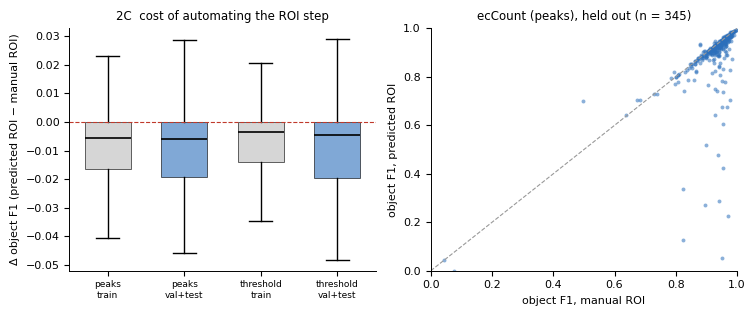

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))

ax = axes[0]
data, labs, cols = [], [], []
for mod in EC:
    for s in subs:
        d = cmp.loc[(cmp.model == mod) & (cmp.subset == s), "delta_obj_f1"].dropna()
        data.append(d)
        labs.append(f"{'peaks' if 'peaks' in mod else 'threshold'}\n{s.split(' (')[0]}")
        cols.append(sc[s])
bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6,
                medianprops=dict(color="black", lw=1.2))
for b, c in zip(bp["boxes"], cols):
    b.set_facecolor(c); b.set_alpha(0.6); b.set_linewidth(0.7)
ax.axhline(0, color="#c0392b", ls="--", lw=0.8)
ax.set_xticklabels(labs, fontsize=6.5)
ax.set_ylabel("Δ object F1 (predicted ROI − manual ROI)")
ax.set_title("2C  cost of automating the ROI step", fontsize=8.5)

ax = axes[1]
d = cmp[(cmp.model == "ecCount (peaks)") & (cmp.subset.str.startswith("val+test"))]
ax.scatter(d.obj_f1_manual, d.obj_f1_pred, s=8, alpha=0.55, lw=0, color="#2c6fbb")
ax.axline((0, 0), slope=1, color="#999999", ls="--", lw=0.8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("object F1, manual ROI"); ax.set_ylabel("object F1, predicted ROI")
ax.set_title(f"ecCount (peaks), held out (n = {len(d)})", fontsize=8.5)

for a in axes:
    for s_ in ("top", "right"):
        a.spines[s_].set_visible(False)
plt.tight_layout()
save(fig, "fig8c_roi_cost_to_eccount")
plt.show()

In [40]:
hd = held
h  = roi_cost[(roi_cost.subset.str.startswith("val+test")) &
              (roi_cost.model == "ecCount (peaks)")].iloc[0]

print(f"""
--- draft for Supplementary Methods §11, numbers from this notebook ---

The ROI-prediction model was trained on the 800-image training split of the
benchmark subset. Agreement metrics computed over all 1,145 benchmark images
therefore include 70% training data and are reported here for completeness only;
all figures quoted below are restricted to the {len(hd)} validation and held-out
test images that the ROI model did not see during training.

Across these {len(hd)} images, predicted ROI masks agreed with manual masks with a
median Dice of {hd.roi_dice.median():.3f} (mean {hd.roi_dice.mean():.3f}, 10th
percentile {hd.roi_dice.quantile(.10):.3f}) and a median IoU of
{hd.roi_iou.median():.3f}. A median of {hd.roi_recall.median():.3f} of the manually
delineated metaphase area was retained.

Of the {int(hd.n_in_manual.sum()):,} annotated ecDNA objects falling inside the
manual ROI, {int(hd.ecdna_lost.sum()):,} ({pct:.2f}%) fell outside the predicted
ROI; median per-image retention was {hd.ecdna_retention.median():.3f} and
{100*(hd.ecdna_lost == 0).mean():.1f}% of images lost no objects. The mean
per-image count shift was {(hd.n_in_pred - hd.n_in_manual).mean():+.2f} ecDNA,
against an ecCount count MAE of 13.1 and signed bias of +0.4.

Substituting predicted for manual ROI masks changed ecCount (peaks) per-image
mean object F1 from {h.F1_manual:.3f} to {h.F1_pred:.3f}
(Δ = {h.mean_delta_F1:+.3f}; Wilcoxon signed-rank P = {h.wilcoxon_p:.2g}).
Predicted ROI masks were not used for any primary performance claim.
--- end draft ---
""")


--- draft for Supplementary Methods §11, numbers from this notebook ---

The ROI-prediction model was trained on the 800-image training split of the
benchmark subset. Agreement metrics computed over all 1,145 benchmark images
therefore include 70% training data and are reported here for completeness only;
all figures quoted below are restricted to the 345 validation and held-out
test images that the ROI model did not see during training.

Across these 345 images, predicted ROI masks agreed with manual masks with a
median Dice of 0.888 (mean 0.857, 10th
percentile 0.752) and a median IoU of
0.799. A median of 0.925 of the manually
delineated metaphase area was retained.

Of the 66,732 annotated ecDNA objects falling inside the
manual ROI, 1,716 (2.57%) fell outside the predicted
ROI; median per-image retention was 0.995 and
44.9% of images lost no objects. The mean
per-image count shift was -4.91 ecDNA,
against an ecCount count MAE of 13.1 and signed bias of +0.4.

Substituting predict